#Member 4 - Interpretation & Documentation
### circRNA-Disease Association Prediction using GraphSAGE + GNNExplainer

**Your 5 tasks:**

| Task | What you do |
|------|-------------|
| Task 1 | Map node IDs to real circRNA / disease names |
| Task 2 | Identify key biological relationships from explanation outputs |
| Task 3 | Analyse ablation & GIP contribution results |
| Task 4 | Write 3 case studies with literature |
| Task 5 | Generate full written report + presentation bullets |

**Run every cell top to bottom using Shift+Enter.**  
No installation needed - all packages are already in your environment.


## STEP 1 - How to Open This Notebook in Jupyter

1. Open **Anaconda Navigator** (or your terminal / command prompt)
2. Click **Launch** on **JupyterLab** (or Jupyter Notebook)
3. In the file browser on the left, navigate to your project folder:
   ```
   project_f/project_f/
   ```
4. Double-click this file: `member4_interpretation.ipynb`
5. Press **Shift+Enter** on each cell to run it, OR click **Run > Run All Cells**

> **Important:** You must open Jupyter from inside `project_f/project_f/` so the
> relative paths match Member 3's notebook exactly.


## STEP 2 - Import Libraries & Set Paths

All packages are already installed (see `results/requirements.txt`). Just run this cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import json
import glob
from pathlib import Path
from IPython.display import Image, display

matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['font.size']  = 11

# --- Paths (same convention as member3_visualization.ipynb) ------------------
# Place this notebook inside:  project_f/project_f/
ROOT   = Path('.').resolve()                          # project_f/project_f/
INTERP = ROOT / 'results' / 'interpretability'       # Member 2 outputs
VIZ    = ROOT / 'results' / 'member3_viz'            # Member 3 outputs
OUT    = ROOT / 'results' / 'member4_interpretation' # YOUR outputs go here
OUT.mkdir(parents=True, exist_ok=True)

print('Libraries loaded')
print('  ROOT   :', ROOT)
print('  INTERP :', INTERP)
print('  VIZ    :', VIZ)
print('  OUT    :', OUT)
print()

# --- Check Member 2 outputs exist before continuing -------------------------
missing = []
for fname in ['edge_importance.csv', 'node_importance.csv']:
    if not (INTERP / fname).exists():
        missing.append(fname)

if missing:
    print('WARNING - MISSING FILES:')
    for f in missing:
        print('  MISSING: results/interpretability/' + f)
    print('Ask Member 2 to run gnn_explainer.py first')
else:
    print('Member 2 output files found - ready to proceed')


Libraries loaded
  ROOT   : C:\Users\Isha Thahaniya\Desktop\project_f\project_f
  INTERP : C:\Users\Isha Thahaniya\Desktop\project_f\project_f\results\interpretability
  VIZ    : C:\Users\Isha Thahaniya\Desktop\project_f\project_f\results\member3_viz
  OUT    : C:\Users\Isha Thahaniya\Desktop\project_f\project_f\results\member4_interpretation

Member 2 output files found - ready to proceed


## STEP 3 - Load Member 2 Outputs

This loads the 4 CSV files produced by Member 2's three scripts:
- `edge_importance.csv` - from `gnn_explainer.py`
- `node_importance.csv` - from `gnn_explainer.py`
- `relation_ablation.csv` - from `relation_ablation.py`
- `gip_quartile_auc.csv` - from `gip_importance.py`

If any are missing, the cell prints a warning and skips that section.

In [2]:
# --- Core outputs (from gnn_explainer.py) -----------------------------------
edge_df = pd.read_csv(INTERP / 'edge_importance.csv')
node_df = pd.read_csv(INTERP / 'node_importance.csv')

print('edge_importance.csv  shape:', edge_df.shape)
print(edge_df.head(3).to_string())
print()
print('node_importance.csv:')
print(node_df.to_string())
print()

# --- Optional: relation ablation (from relation_ablation.py) ----------------
try:
    ablation_df = pd.read_csv(INTERP / 'relation_ablation.csv')
    print('relation_ablation.csv loaded  shape:', ablation_df.shape)
except FileNotFoundError:
    ablation_df = None
    print('WARNING: relation_ablation.csv not found')
    print('  Ask Member 2 to run: python relation_ablation.py')

# --- Optional: GIP quartile data (from gip_importance.py) ------------------
try:
    gip_df = pd.read_csv(INTERP / 'gip_quartile_auc.csv')
    print('gip_quartile_auc.csv loaded   shape:', gip_df.shape)
except FileNotFoundError:
    gip_df = None
    print('WARNING: gip_quartile_auc.csv not found')
    print('  Ask Member 2 to run: python gip_importance.py')


edge_importance.csv  shape: (100480, 7)
   pair_idx group     edge_src_name            edge_dst_name edge_src_type edge_dst_type  importance
0       119   top  hsa_circ_0001859    arthritis, rheumatoid       circRNA       disease    0.206347
1       119   top   circrna-0004904            pre-eclampsia       circRNA       disease    0.206347
2       119   top     circrna_09993  tuberculosis, pulmonary       circRNA       disease    0.206347

node_importance.csv:
             feature  mean_importance  std_importance  rank
0             degree         0.425608        0.269111     1
1  betweenness_proxy         0.270220        0.175169     2
2         log_degree         0.251768        0.140006     3
3         is_circRNA         0.244494        0.151223     4
4         is_disease         0.229170        0.124894     5
5           is_miRNA         0.209297        0.031210     6

relation_ablation.csv loaded  shape: (5, 7)
gip_quartile_auc.csv loaded   shape: (4, 4)


## STEP 4 - Task 1: Map Node IDs to Real Names

Inside the graph, every node is stored as an integer:
- IDs `0 ... n_circ-1` are circRNA nodes
- IDs `n_circ ... N-1` are disease nodes

Member 2's `gnn_explainer.py` already resolved these integers to real names
and stored them in `edge_src_name` and `edge_dst_name` columns.

This step extracts all unique names and saves clean lookup lists.

In [3]:
# --- Extract all unique circRNA names from the edge data --------------------
circrna_names = sorted(set(
    edge_df[edge_df['edge_src_type'] == 'circRNA']['edge_src_name'].tolist() +
    edge_df[edge_df['edge_dst_type'] == 'circRNA']['edge_dst_name'].tolist()
))

# --- Extract all unique disease names ----------------------------------------
disease_names = sorted(set(
    edge_df[edge_df['edge_src_type'] == 'disease']['edge_src_name'].tolist() +
    edge_df[edge_df['edge_dst_type'] == 'disease']['edge_dst_name'].tolist()
))

print('Unique circRNA nodes in explanations:', len(circrna_names))
print('Unique disease nodes in explanations:', len(disease_names))

print('\ncircRNA names (first 15):')
for n in circrna_names[:15]:
    print('  ', n)

print('\nDisease names (first 15):')
for n in disease_names[:15]:
    print('  ', n)

# --- Save name lists ---------------------------------------------------------
pd.DataFrame({'circRNA': circrna_names}).to_csv(OUT / 'circrna_name_list.csv', index=False)
pd.DataFrame({'disease': disease_names}).to_csv(OUT / 'disease_name_list.csv', index=False)
print('\nSaved: circrna_name_list.csv  and  disease_name_list.csv')


Unique circRNA nodes in explanations: 789
Unique disease nodes in explanations: 119

circRNA names (first 15):
   bcrc-3
   cbl.11
   cdr1as
   cir-ccdc66
   circ kmt2e
   circ-abcb10
   circ-acaca
   circ-adam9
   circ-akt3
   circ-anapc7
   circ-ash2l
   circ-atp8a2
   circ-banp
   circ-cbfb
   circ-cdc45

Disease names (first 15):
   acne vulgaris
   active pulmonary tuberculosis
   active tuberculosis
   adenocarcinoma of lung
   alzheimer disease
   aortic aneurysm
   arthritis, rheumatoid
   atherosclerosis
   bladder urothelial carcinoma
   breast neoplasms
   carcinoma, hepatocellular
   carcinoma, mucoepidermoid
   carcinoma, non-small-cell lung
   carcinoma, ovarian epithelial
   carcinoma, pancreatic ductal

Saved: circrna_name_list.csv  and  disease_name_list.csv


## STEP 5 - Task 2: Top Predicted circRNA-Disease Associations

Filter only **circRNA to disease** edges (the biological prediction edges),
then rank by average GNNExplainer importance score across all explained pairs.

In [4]:
# --- Keep only direct circRNA->disease edges --------------------------------
cd_edges = edge_df[
    (edge_df['edge_src_type'] == 'circRNA') &
    (edge_df['edge_dst_type'] == 'disease')
].copy()

print('Total circRNA->disease edge rows:', len(cd_edges))

# --- Aggregate: mean importance per unique (circRNA, disease) pair -----------
top_assoc = (
    cd_edges
    .groupby(['edge_src_name', 'edge_dst_name'])['importance']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={
        'edge_src_name': 'circRNA',
        'edge_dst_name': 'disease',
        'mean':  'mean_importance',
        'std':   'std_importance',
        'count': 'n_explanations'
    })
    .sort_values('mean_importance', ascending=False)
    .reset_index(drop=True)
)
top_assoc['rank'] = top_assoc.index + 1

print('\nTOP 20 MOST IMPORTANT circRNA-DISEASE ASSOCIATIONS')
print('=' * 65)
print(top_assoc.head(20)[['rank','circRNA','disease','mean_importance','n_explanations']].to_string(index=False))

top_assoc.to_csv(OUT / 'top_associations.csv', index=False)
print('\nSaved: top_associations.csv')


Total circRNA->disease edge rows: 15760

TOP 20 MOST IMPORTANT circRNA-DISEASE ASSOCIATIONS
 rank     circRNA                                  disease  mean_importance  n_explanations
    1      cdr1as                 nasopharyngeal carcinoma         0.278806              20
    2      cdr1as                             osteosarcoma         0.278806              20
    3      cdr1as                        stomach neoplasms         0.278806              20
    4      cdr1as                urinary bladder neoplasms         0.278806              20
    5      cdr1as squamous cell carcinoma of head and neck         0.278806              20
    6   circ-itch                           lung neoplasms         0.268608              20
    7   circ-itch                             osteosarcoma         0.268608              20
    8   circ-itch                        ovarian neoplasms         0.268608              20
    9   circ-itch                      prostatic neoplasms         0.268608     

## STEP 6 - Task 2: Edge Type Importance

Which *type* of connection does the model rely on most?

| Edge Type | Meaning |
|-----------|----------|
| `circRNA-disease` | Direct biological association (the prediction target) |
| `disease-circRNA` | Reverse of the same |
| `GIP_circRNA-circRNA` | GIP similarity between circRNAs |
| `GIP_disease-disease` | GIP similarity between diseases |

In [5]:
# --- Mean importance grouped by edge type -----------------------------------
edge_type_summary = (
    edge_df
    .groupby('edge_dst_type')['importance']
    .agg(['mean','std','count'])
    .reset_index()
    .sort_values('mean', ascending=False)
    .rename(columns={'mean':'mean_importance','std':'std_importance','count':'n_edges'})
)
 

print('EDGE TYPE IMPORTANCE SUMMARY')
print('=' * 55)
print(edge_type_summary.to_string(index=False))

top_etype = edge_type_summary.iloc[0]
bot_etype = edge_type_summary.iloc[-1]

print('\nMost relied-upon edge type :', top_etype['edge_dst_type'],
      '  mean =', round(top_etype['mean_importance'],4))
print('Least relied-upon edge type:', bot_etype['edge_dst_type'],
      '  mean =', round(bot_etype['mean_importance'],4))

edge_type_summary.to_csv(OUT / 'edge_type_summary.csv', index=False)
print('\nSaved: edge_type_summary.csv')


EDGE TYPE IMPORTANCE SUMMARY
edge_dst_type  mean_importance  std_importance  n_edges
        miRNA         0.249015        0.149640    34480
      circRNA         0.247277        0.146222    33680
      disease         0.244469        0.140078    32320

Most relied-upon edge type : miRNA   mean = 0.249
Least relied-upon edge type: disease   mean = 0.2445

Saved: edge_type_summary.csv


## STEP 7 - Task 2: Node Feature Importance

| Feature | Biological meaning |
|---------|--------------------|
| `degree` | How many direct connections the node has |
| `log_degree` | Log-scaled degree (reduces hub dominance) |
| `betweenness` | How often this node bridges other nodes |
| `is_circRNA` | Is this a circRNA node? (1 or 0) |
| `is_miRNA` | Is this a miRNA node? (1 or 0) |
| `is_disease` | Is this a disease node? (1 or 0) |

In [6]:
print('NODE FEATURE IMPORTANCE RANKING')
print('=' * 58)
print(node_df[['rank','feature','mean_importance','std_importance']].to_string(index=False))

top_feat = node_df.iloc[0]
sec_feat = node_df.iloc[1] if len(node_df) > 1 else node_df.iloc[0]

print('\n#1 feature:', top_feat['feature'],
      '  importance =', round(top_feat['mean_importance'],4),
      'plus/minus', round(top_feat['std_importance'],4))
print('#2 feature:', sec_feat['feature'],
      '  importance =', round(sec_feat['mean_importance'],4),
      'plus/minus', round(sec_feat['std_importance'],4))

structural = node_df[node_df['feature'].isin(['degree','log_degree','betweenness'])]['mean_importance'].sum()
type_flags  = node_df[node_df['feature'].isin(['is_circRNA','is_miRNA','is_disease'])]['mean_importance'].sum()
total       = structural + type_flags + 1e-9

print('\nStructural features (degree/log/betweenness):', round(structural,4),
      '=', round(100*structural/total,1), '% of total')
print('Node-type flags (is_circRNA/is_disease)     :', round(type_flags,4),
      '=', round(100*type_flags/total,1), '% of total')

if structural > type_flags:
    print('\nConclusion: Model relies more on GRAPH STRUCTURE (topology)')
else:
    print('\nConclusion: Model relies more on NODE IDENTITY (type flags)')


NODE FEATURE IMPORTANCE RANKING
 rank           feature  mean_importance  std_importance
    1            degree         0.425608        0.269111
    2 betweenness_proxy         0.270220        0.175169
    3        log_degree         0.251768        0.140006
    4        is_circRNA         0.244494        0.151223
    5        is_disease         0.229170        0.124894
    6          is_miRNA         0.209297        0.031210

#1 feature: degree   importance = 0.4256 plus/minus 0.2691
#2 feature: betweenness_proxy   importance = 0.2702 plus/minus 0.1752

Structural features (degree/log/betweenness): 0.6774 = 49.8 % of total
Node-type flags (is_circRNA/is_disease)     : 0.683 = 50.2 % of total

Conclusion: Model relies more on NODE IDENTITY (type flags)


## STEP 8 - Task 3: Relation Ablation Study

`relation_ablation.py` removed each edge type one at a time, retrained the model,
and recorded the AUC/AUPR drop.

**Key question:** Which edge type causes the biggest performance drop when removed?
That is the most critical edge type for the model.

In [7]:
if ablation_df is not None:
    print('RELATION ABLATION RESULTS')
    print('=' * 68)
    cols = [c for c in ['ablation','mean_auc','mean_aupr','delta_auc','delta_aupr','pct_drop_auc']
            if c in ablation_df.columns]
    print(ablation_df[cols].to_string(index=False))

    non_base = ablation_df[ablation_df['ablation'] != 'baseline'].copy()
    if 'delta_auc' in non_base.columns:
        worst = non_base.sort_values('delta_auc').iloc[0]
        best  = non_base.sort_values('delta_auc').iloc[-1]
        print('\nMOST critical edge type :', worst['ablation'])
        print('  Removing it causes AUC drop of:', round(worst['delta_auc'],4))
        print('LEAST critical edge type:', best['ablation'])
        print('  Removing it changes AUC by:', round(best['delta_auc'],4))

    ablation_df.to_csv(OUT / 'ablation_interpretation.csv', index=False)
    print('\nSaved: ablation_interpretation.csv')
else:
    print('Ablation data not available.')
    print('Ask Member 2 to run: python relation_ablation.py')
    print('Output: results/interpretability/relation_ablation.csv')


RELATION ABLATION RESULTS
                  ablation  mean_auc  mean_aupr  delta_auc  delta_aupr
  mask GIP disease–disease  0.488498   0.511716  -0.220938   -0.118600
        mask ALL GIP edges  0.656121   0.603507  -0.053315   -0.026810
  mask GIP circRNA–circRNA  0.697501   0.632075  -0.011935    0.001759
                  baseline  0.709436   0.630316   0.000000    0.000000
mask circRNA–disease edges  0.806444   0.815851   0.097008    0.185535

MOST critical edge type : mask GIP disease–disease
  Removing it causes AUC drop of: -0.2209
LEAST critical edge type: mask circRNA–disease edges
  Removing it changes AUC by: 0.097

Saved: ablation_interpretation.csv


## STEP 9 - Task 3: GIP Contribution by Degree Quartile

`gip_importance.py` trained the model WITH and WITHOUT GIP edges,
split by circRNA degree quartile.

| Quartile | Meaning |
|----------|---------|
| Q1 (low) | fewest biological connections - least studied circRNAs |
| Q4 (high) | most connections - well-studied circRNAs |

**Hypothesis:** GIP similarity should help Q1 (data-sparse) circRNAs most.

In [8]:
if gip_df is not None:
    print('GIP CONTRIBUTION BY DEGREE QUARTILE')
    print('=' * 55)
    print(gip_df.to_string(index=False))

    q1_row = gip_df[gip_df['quartile'].str.contains('Q1')]
    q4_row = gip_df[gip_df['quartile'].str.contains('Q4')]

    if len(q1_row) and len(q4_row):
        q1_val = q1_row['mean_delta_auc'].values[0]
        q4_val = q4_row['mean_delta_auc'].values[0]
        print('\nQ1 (low-degree)  delta_AUC =', round(q1_val,4))
        print('Q4 (high-degree) delta_AUC =', round(q4_val,4))
        if q1_val > q4_val:
            print('\nConclusion: GIP edges help LOW-DEGREE circRNAs MORE.')
            print('  GIP similarity compensates for sparse biological data.')
        else:
            print('\nConclusion: GIP edges do NOT preferentially help low-degree circRNAs.')
            print('  The GIP signal may be redundant with existing graph structure.')

    gip_df.to_csv(OUT / 'gip_interpretation.csv', index=False)
    print('\nSaved: gip_interpretation.csv')
else:
    print('GIP data not available.')
    print('Ask Member 2 to run: python gip_importance.py')
    print('Output: results/interpretability/gip_quartile_auc.csv')


GIP CONTRIBUTION BY DEGREE QUARTILE
 quartile  n_nodes  mean_delta_auc  std_delta_auc
 Q1 (low)      186        0.070341       0.604656
       Q2        0             NaN            NaN
       Q3        0             NaN            NaN
Q4 (high)       15       -0.016667       0.520150

Q1 (low-degree)  delta_AUC = 0.0703
Q4 (high-degree) delta_AUC = -0.0167

Conclusion: GIP edges help LOW-DEGREE circRNAs MORE.
  GIP similarity compensates for sparse biological data.

Saved: gip_interpretation.csv


## STEP 10 - Task 4: Case Studies (Top 3 Predictions)

This cell shows your top 3 circRNA-disease predictions with PubMed search links.

**What you must do manually AFTER running this cell:**
1. Ctrl+click each PubMed link to open it in your browser
2. Search for the circRNA-disease pair in literature
3. Open `results/member4_interpretation/case_studies.json`
4. Fill in `literature_note` for each case:
   - If paper found: `Validated in [Author et al., Year, Journal]`
   - If not found: `Novel prediction - not yet experimentally confirmed`

In [9]:
print('TOP 3 cirRNA-DISEASE ASSOCIATIONS - CASE STUDIES')
print('=' * 65)

case_studies = []
for _, row in top_assoc.head(3).iterrows():
    circ    = row['circRNA']
    disease = row['disease']
    score   = row['mean_importance']

    query  = (circ + ' ' + disease).replace(' ', '+')
    pubmed = 'https://pubmed.ncbi.nlm.nih.gov/?term=' + query

    print('\nRank', int(row['rank']), ':')
    print('  circRNA    :', circ)
    print('  Disease    :', disease)
    print('  Importance :', round(score,4))
    print('  PubMed URL :', pubmed)

    case_studies.append({
        'rank'             : int(row['rank']),
        'circRNA'          : circ,
        'disease'          : disease,
        'importance_score' : round(float(score),4),
        'n_explained_pairs': int(row['n_explanations']),
        'literature_note'  : 'TODO - search PubMed and fill this in',
        'pubmed_url'       : pubmed
    })

with open(OUT / 'case_studies.json', 'w') as f:
    json.dump(case_studies, f, indent=2)

print('\nSaved: case_studies.json')
print('  Open it and fill in literature_note for each case')


TOP 3 cirRNA-DISEASE ASSOCIATIONS - CASE STUDIES

Rank 1 :
  circRNA    : cdr1as
  Disease    : nasopharyngeal carcinoma
  Importance : 0.2788
  PubMed URL : https://pubmed.ncbi.nlm.nih.gov/?term=cdr1as+nasopharyngeal+carcinoma

Rank 2 :
  circRNA    : cdr1as
  Disease    : osteosarcoma
  Importance : 0.2788
  PubMed URL : https://pubmed.ncbi.nlm.nih.gov/?term=cdr1as+osteosarcoma

Rank 3 :
  circRNA    : cdr1as
  Disease    : stomach neoplasms
  Importance : 0.2788
  PubMed URL : https://pubmed.ncbi.nlm.nih.gov/?term=cdr1as+stomach+neoplasms

Saved: case_studies.json
  Open it and fill in literature_note for each case


## STEP 11 - Task 4: Display Member 3 Visualizations

Shows all plots from Member 3 inline in the notebook.
These become the figures in your written report.

Found 13 visualization files:
  plot1_feature_importance.png                        (43.3 KB)


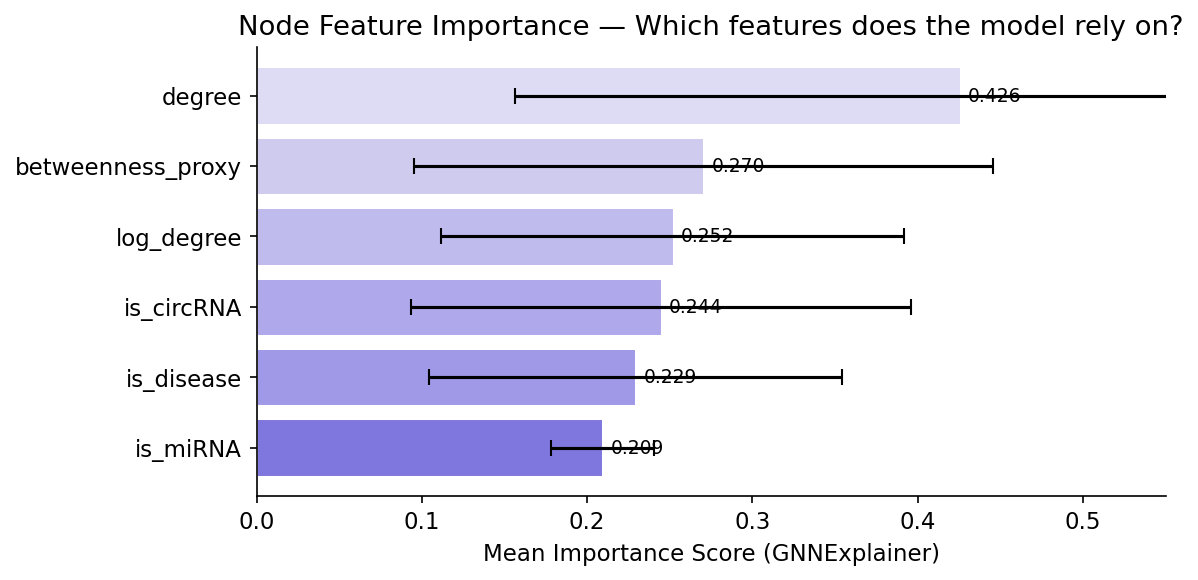

  plot2_edge_type_importance.png                      (60.5 KB)


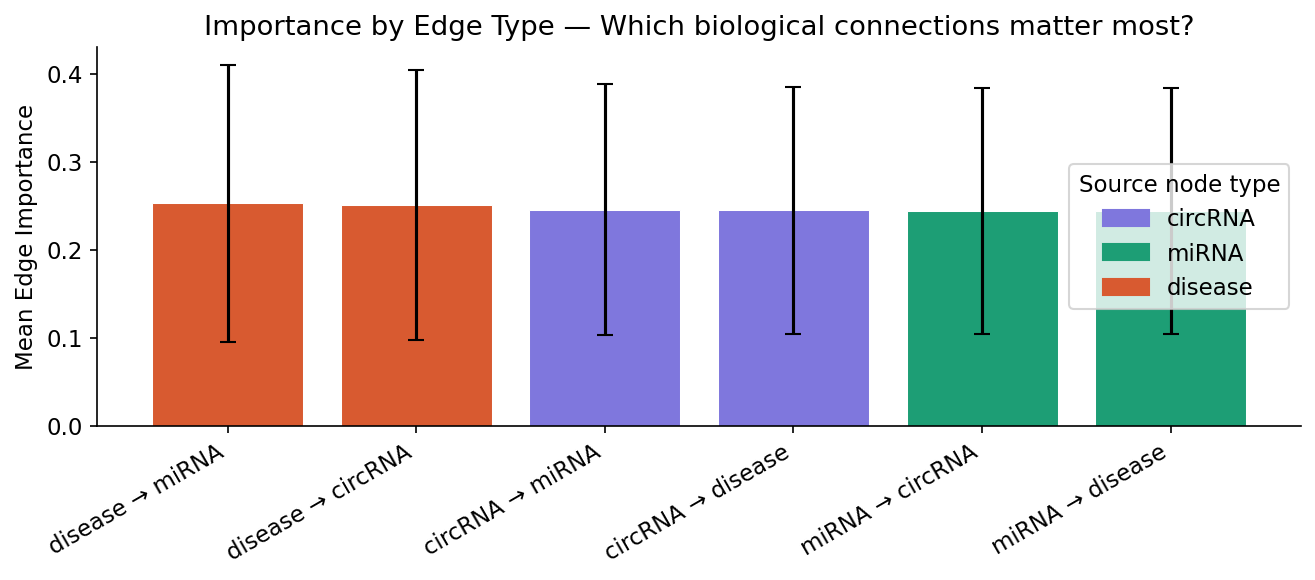

  plot3_top_vs_random.png                             (62.5 KB)


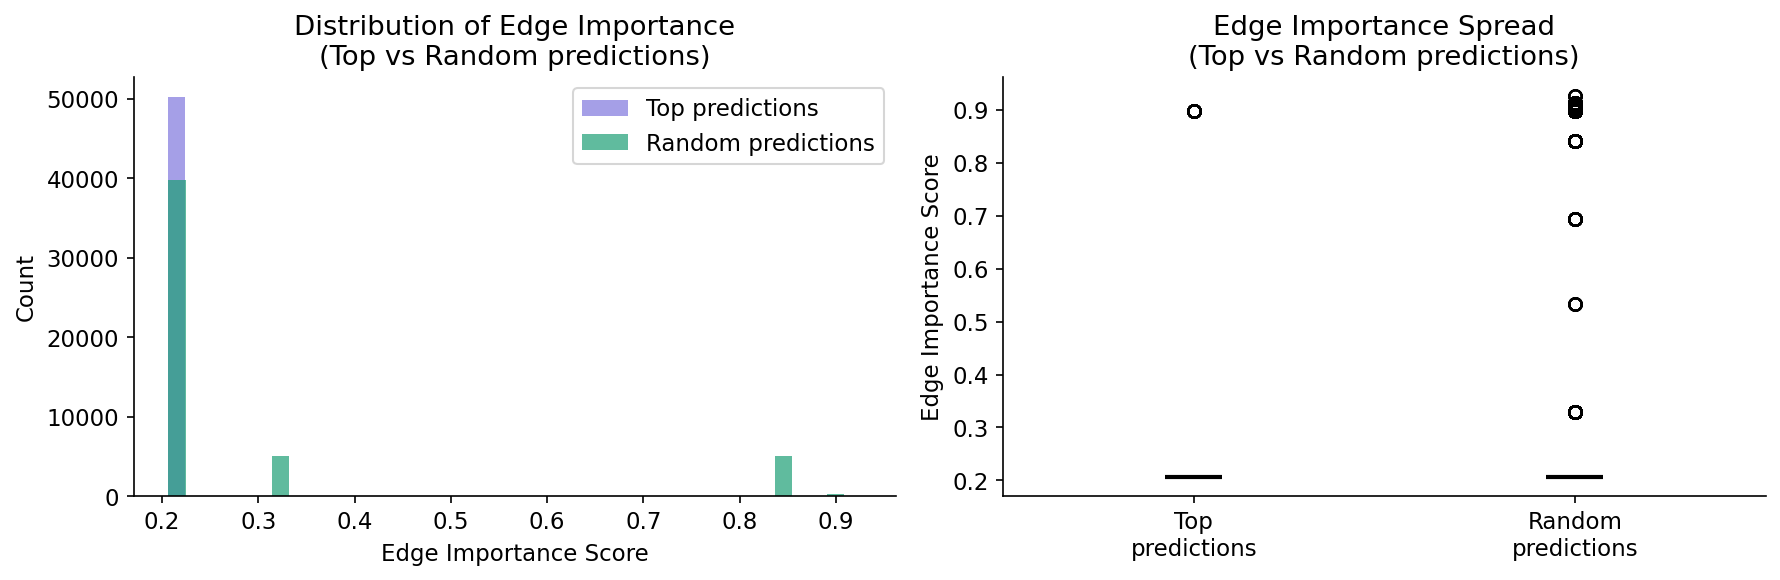

  plot4_top20_edges.png                               (159.2 KB)


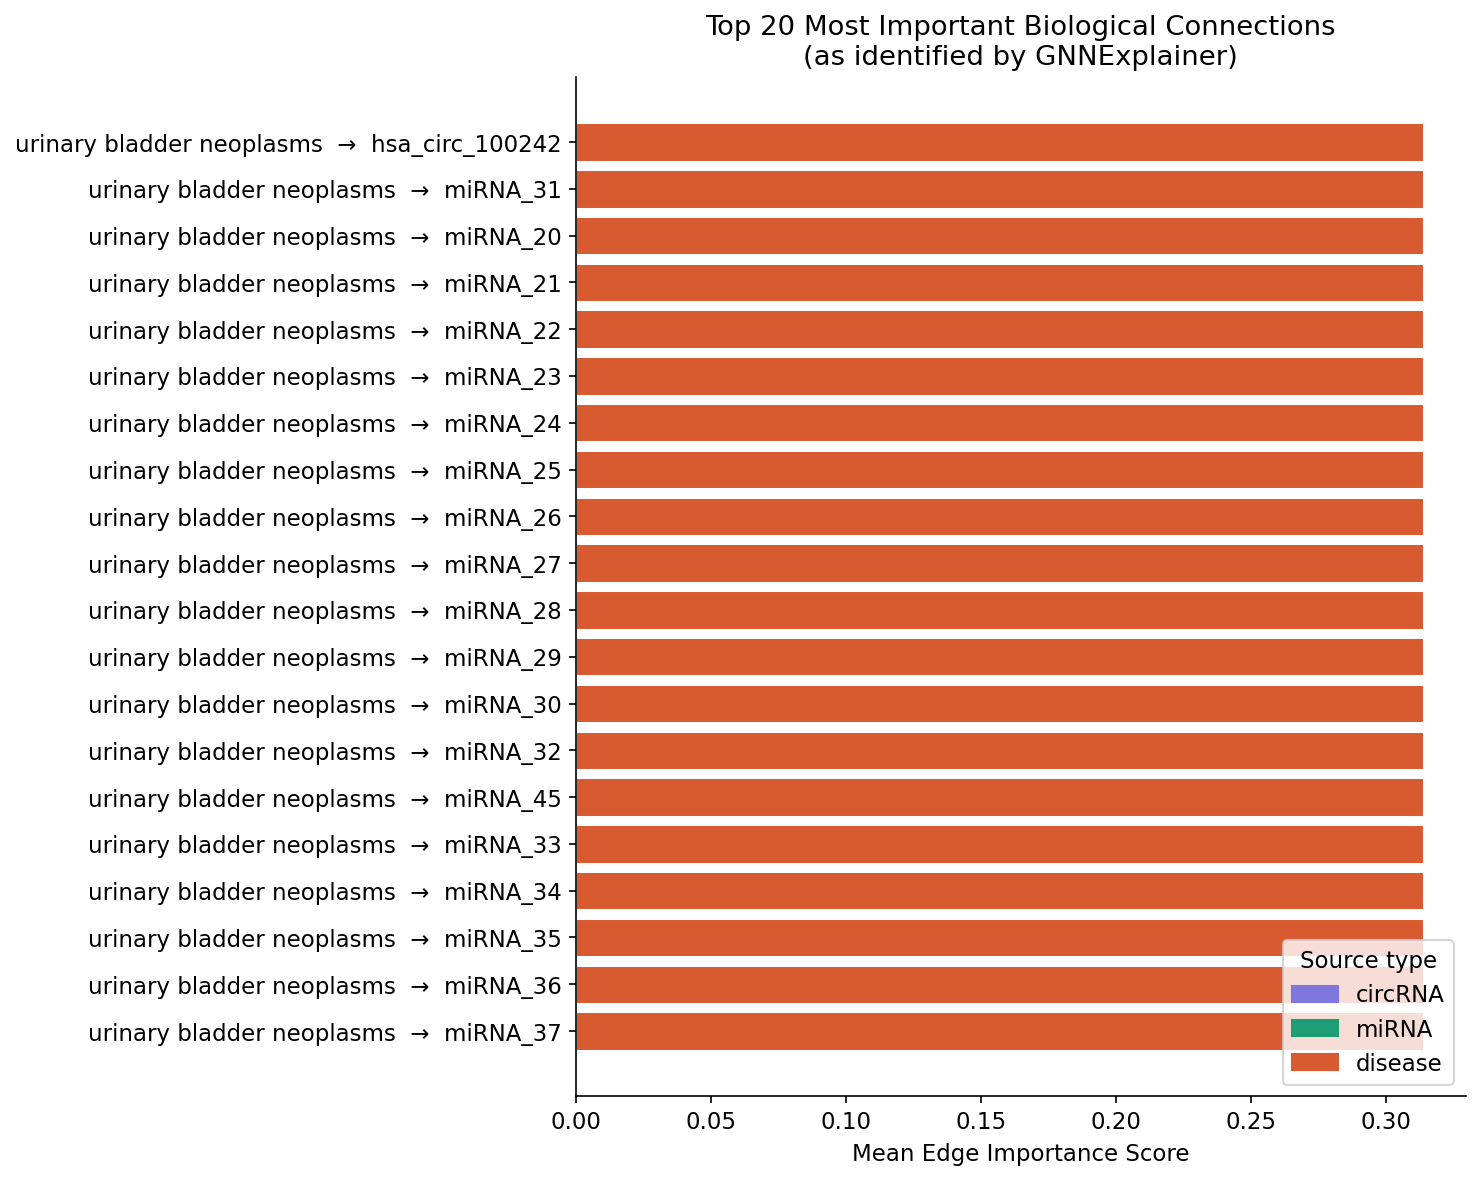

  plot5_subgraph_top_prediction.png                   (335.3 KB)


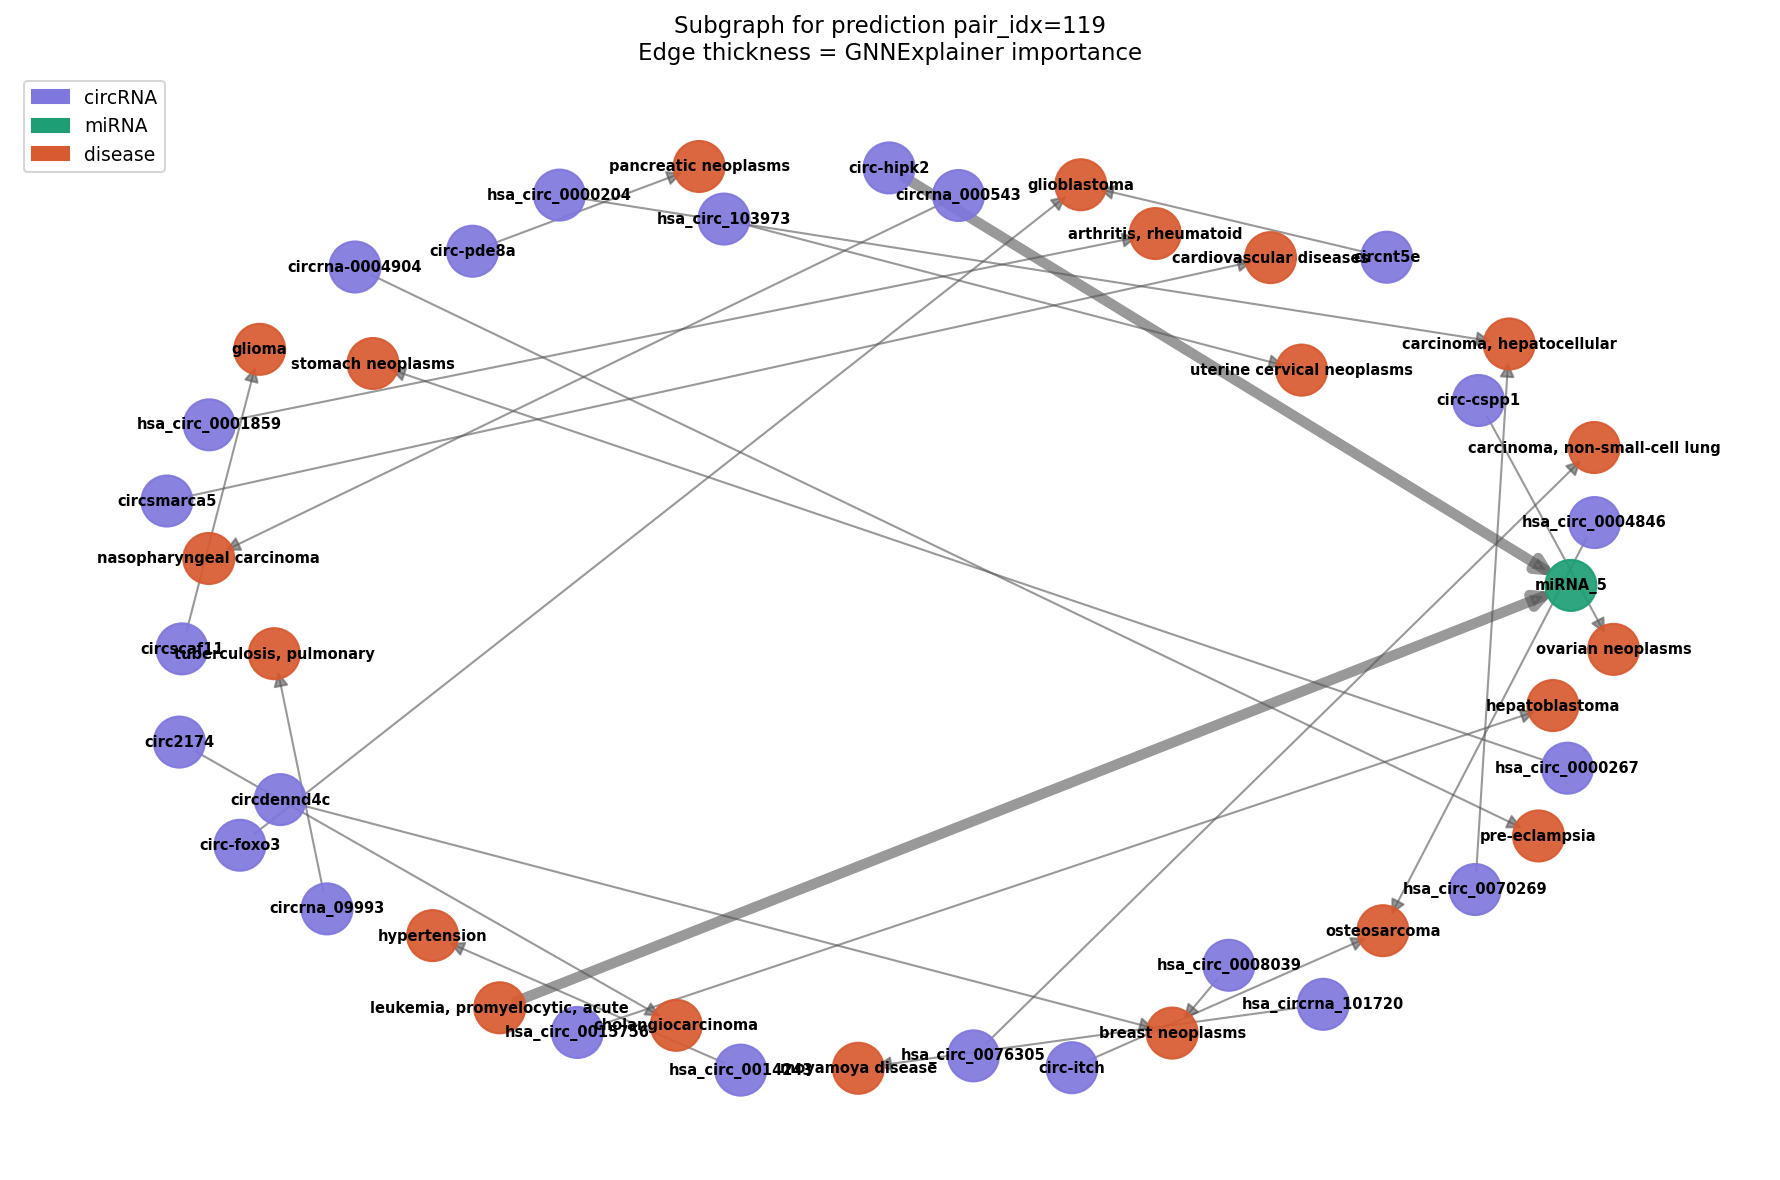

  plot6_top4_subgraphs.png                            (672.7 KB)


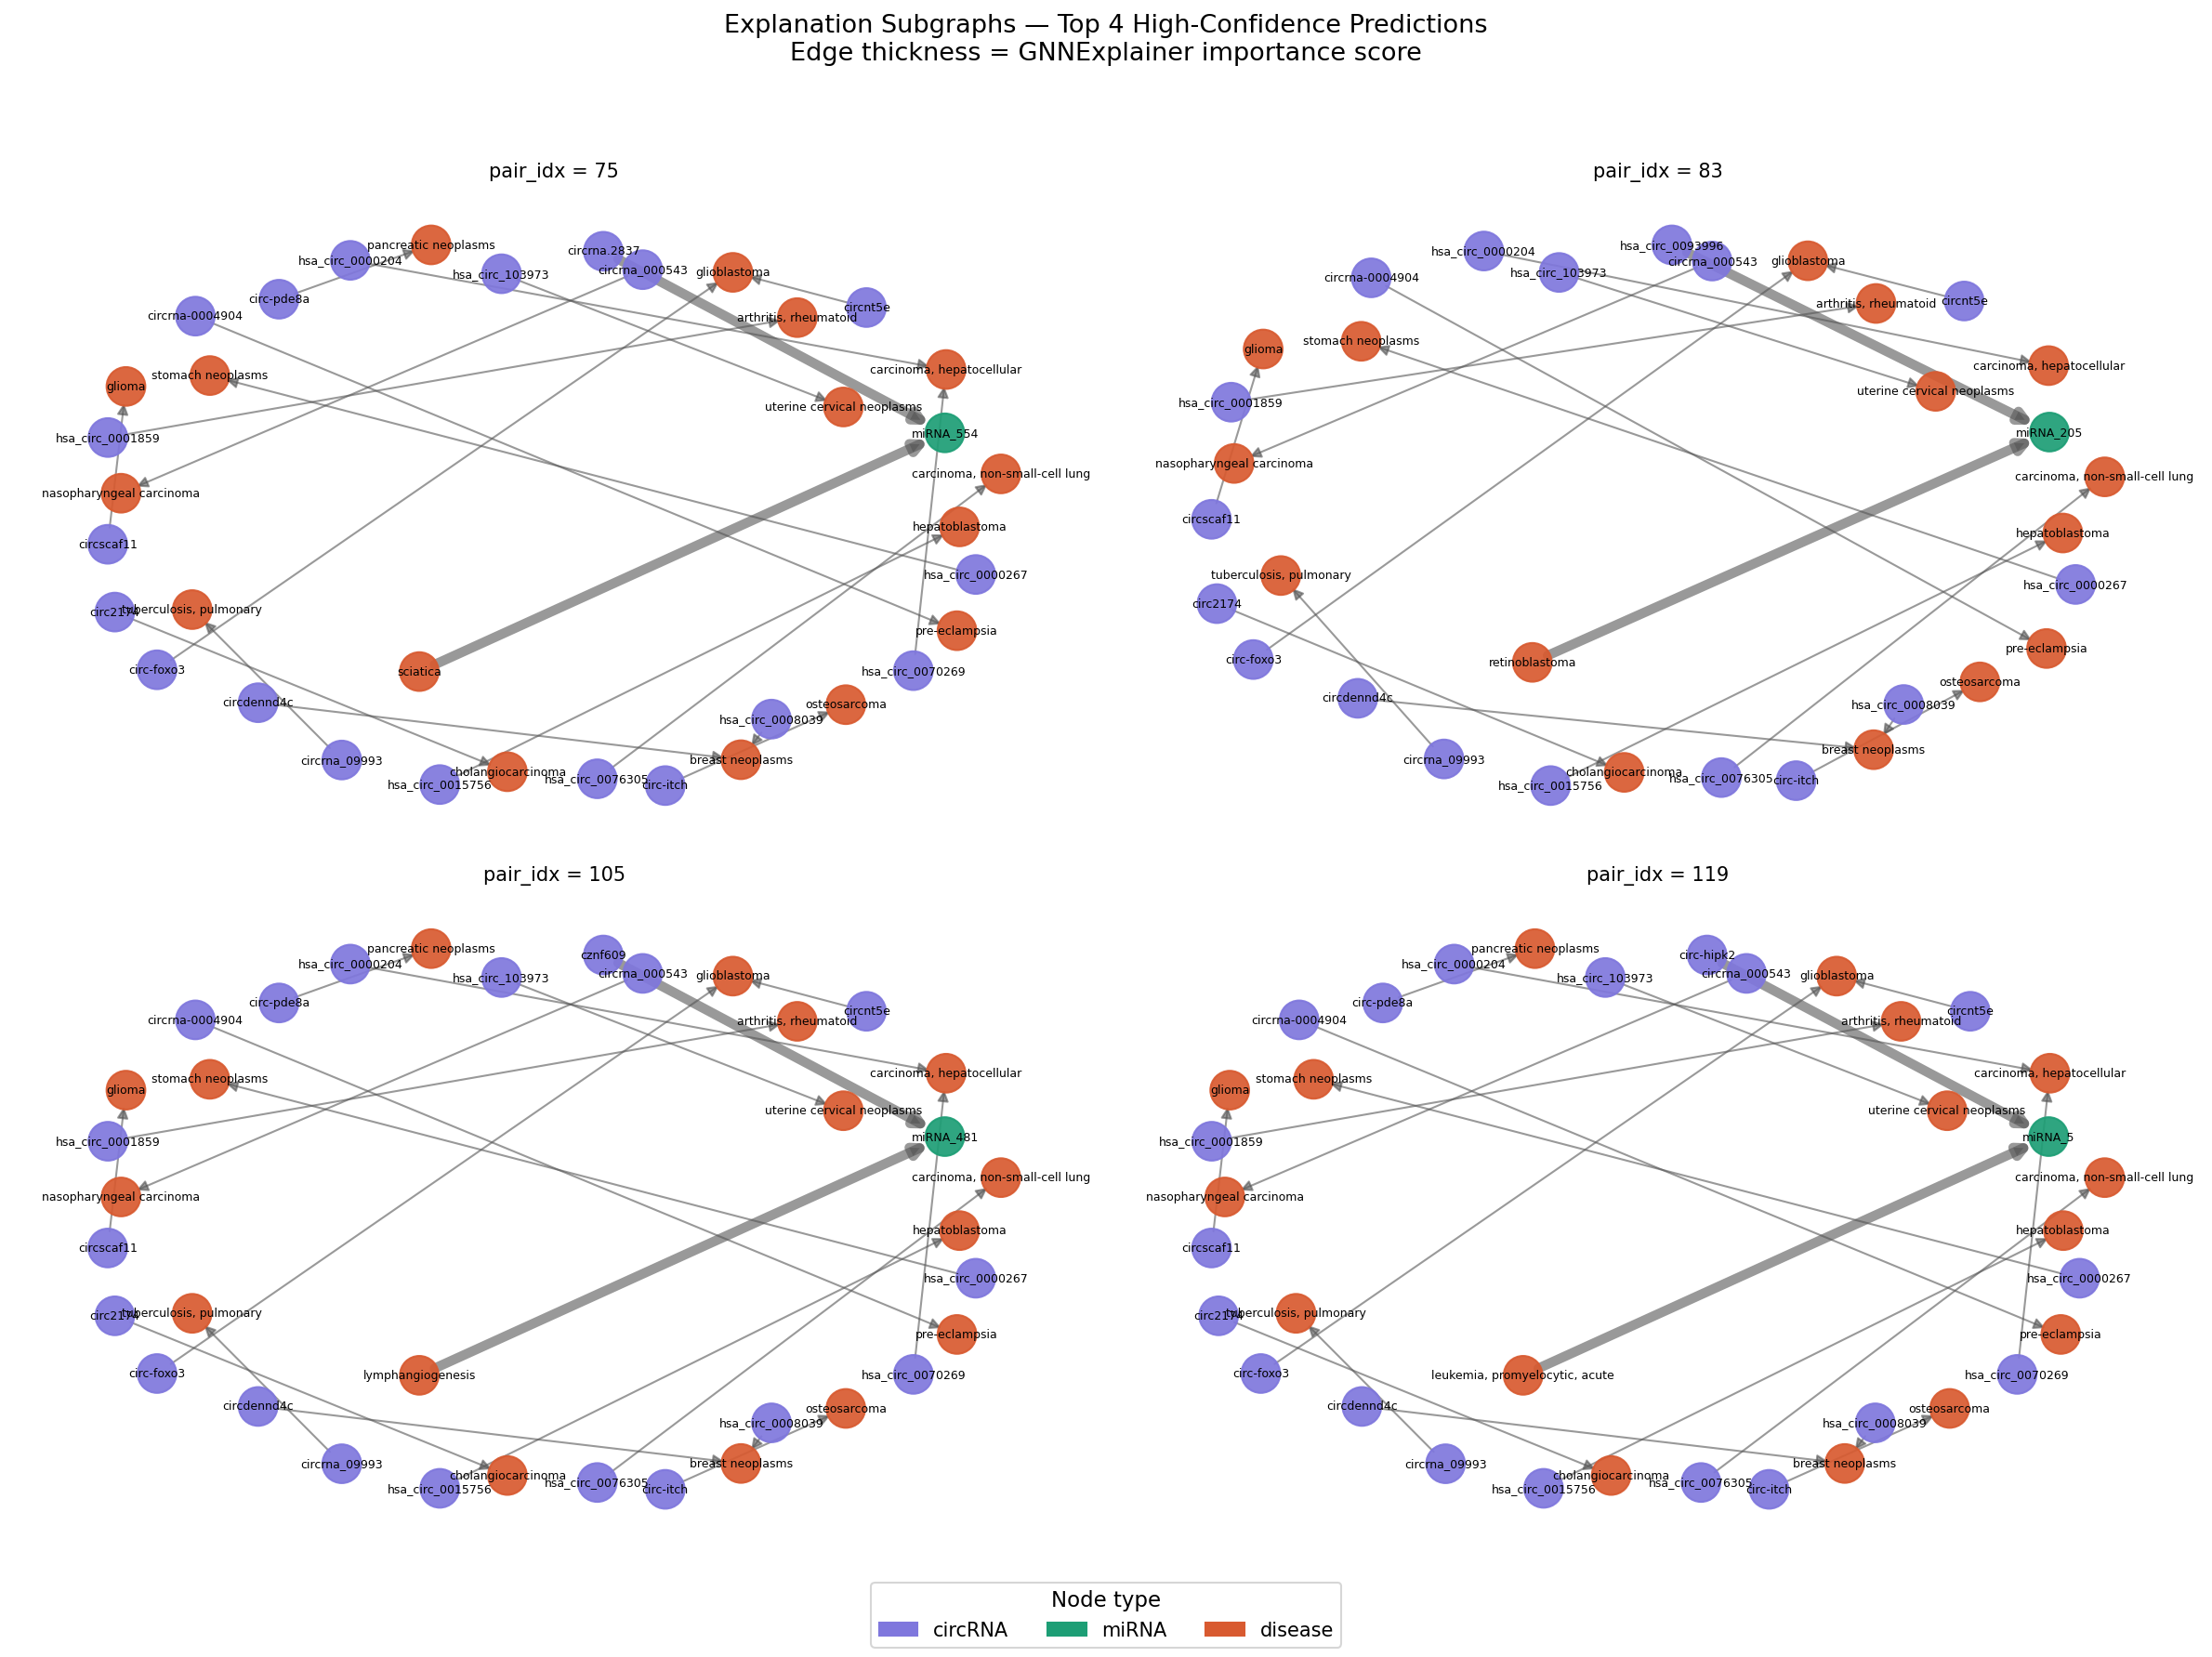

  plot7_important_vs_nonimportant.png                 (80.9 KB)


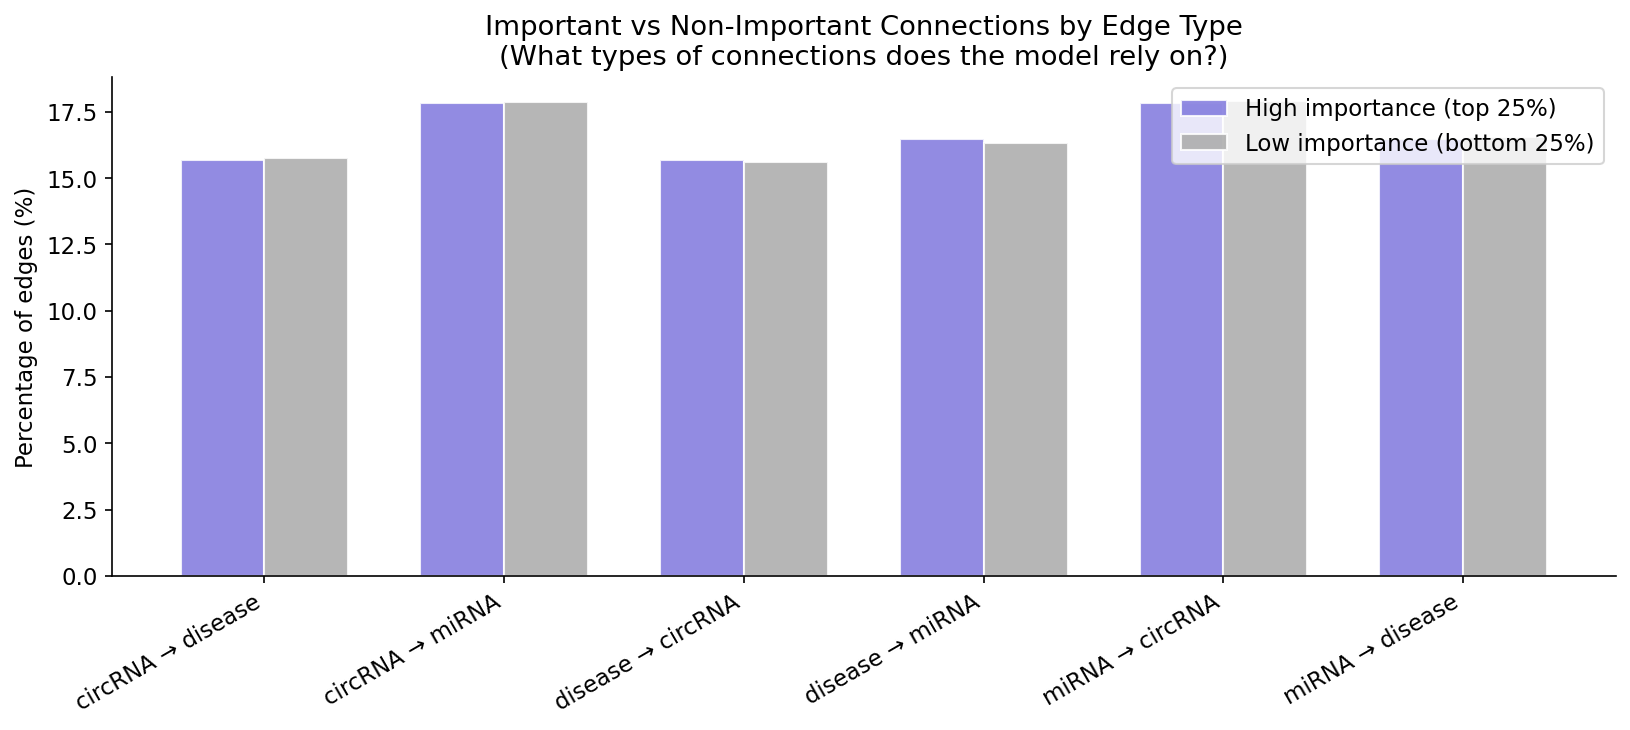

  plot8_feature_radar.png                             (99.4 KB)


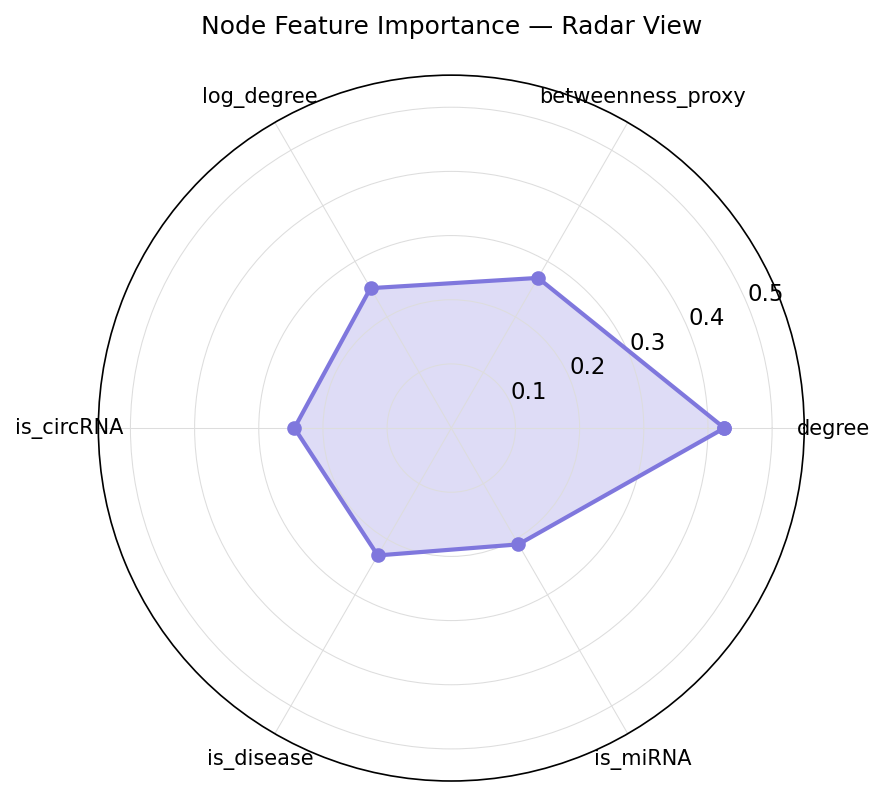

  cosine_similarity_distributions.png                 (51.4 KB)


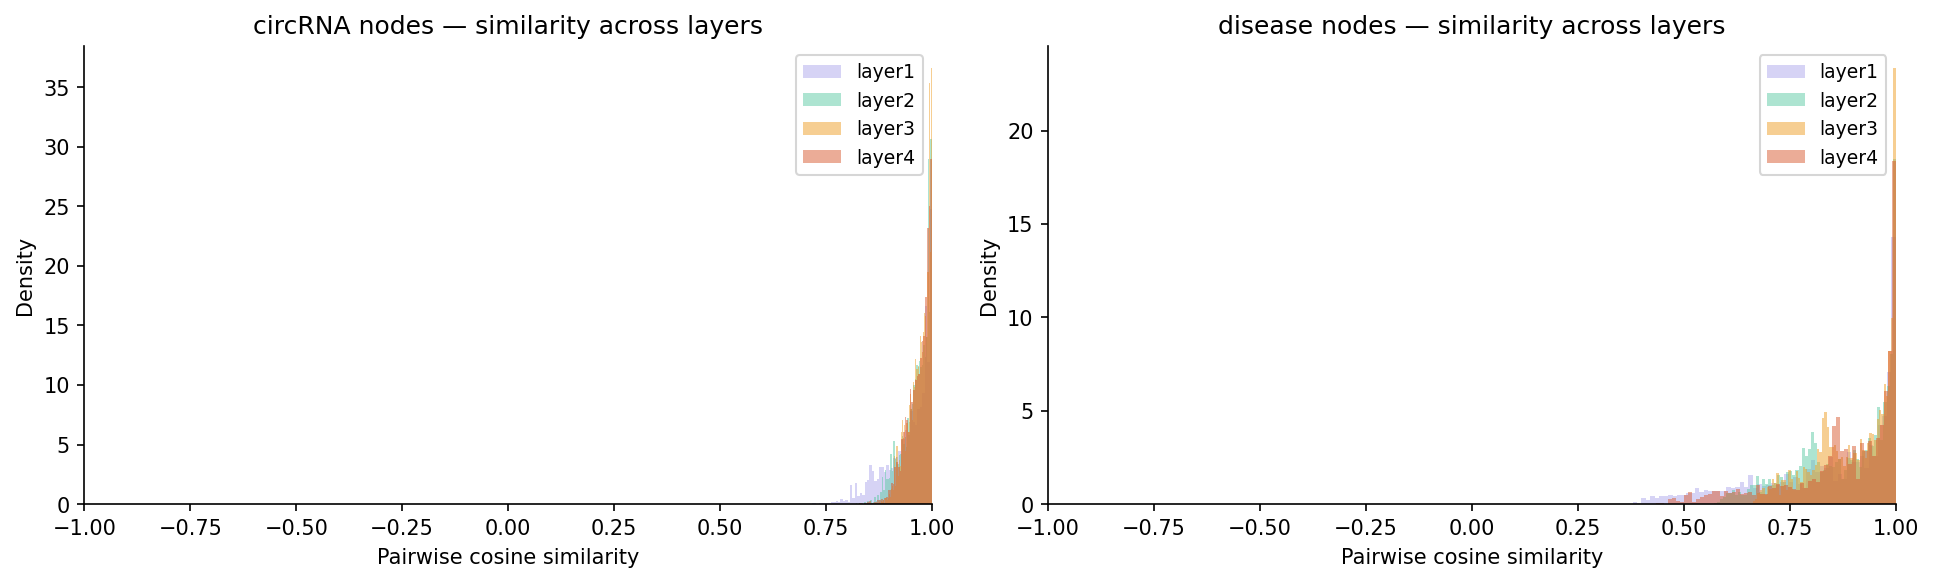

  edge_importance_bar.png                             (168.9 KB)


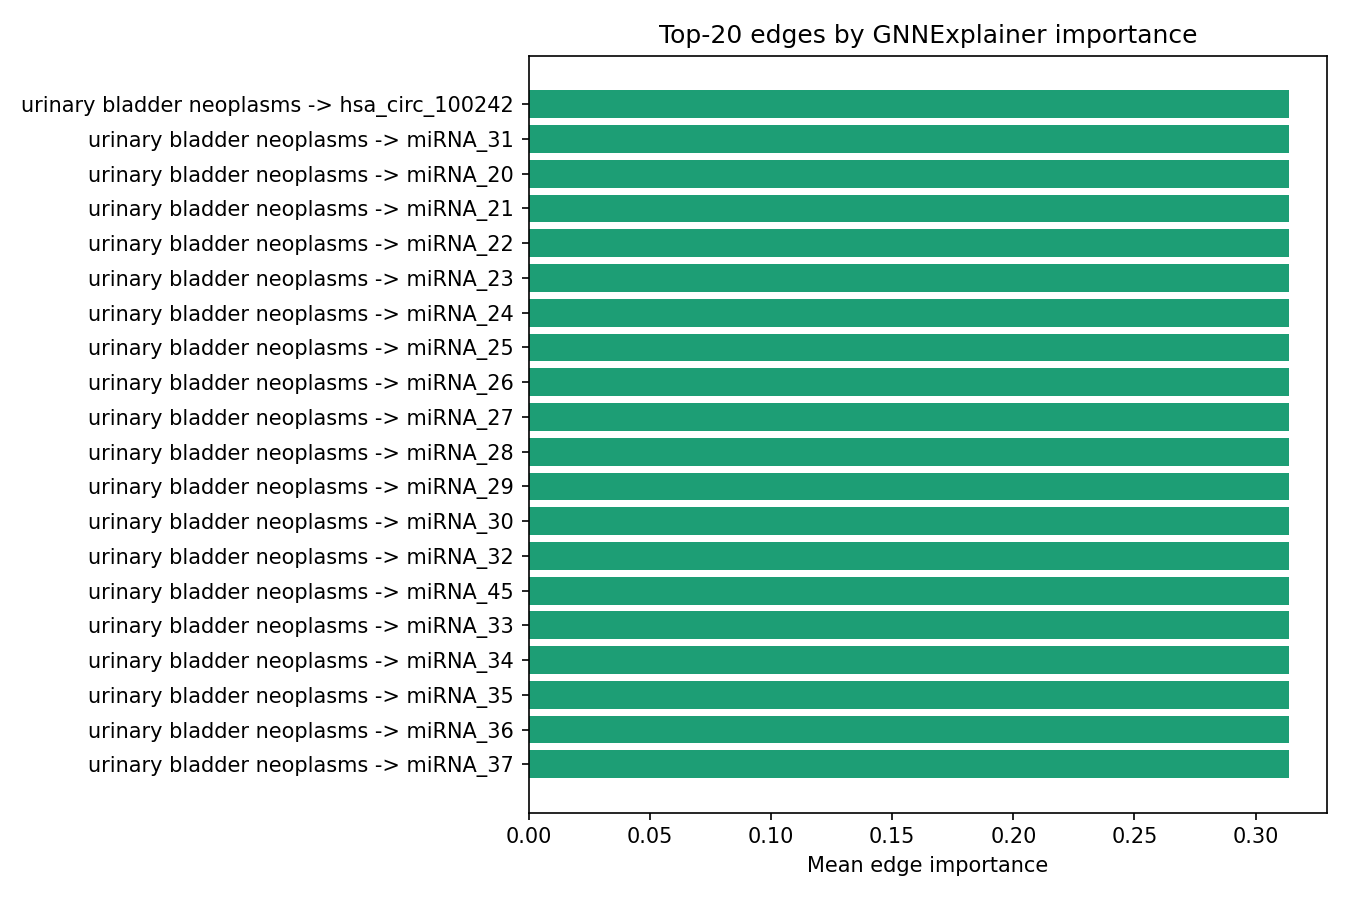

  gip_quartile_auc.png                                (47.4 KB)


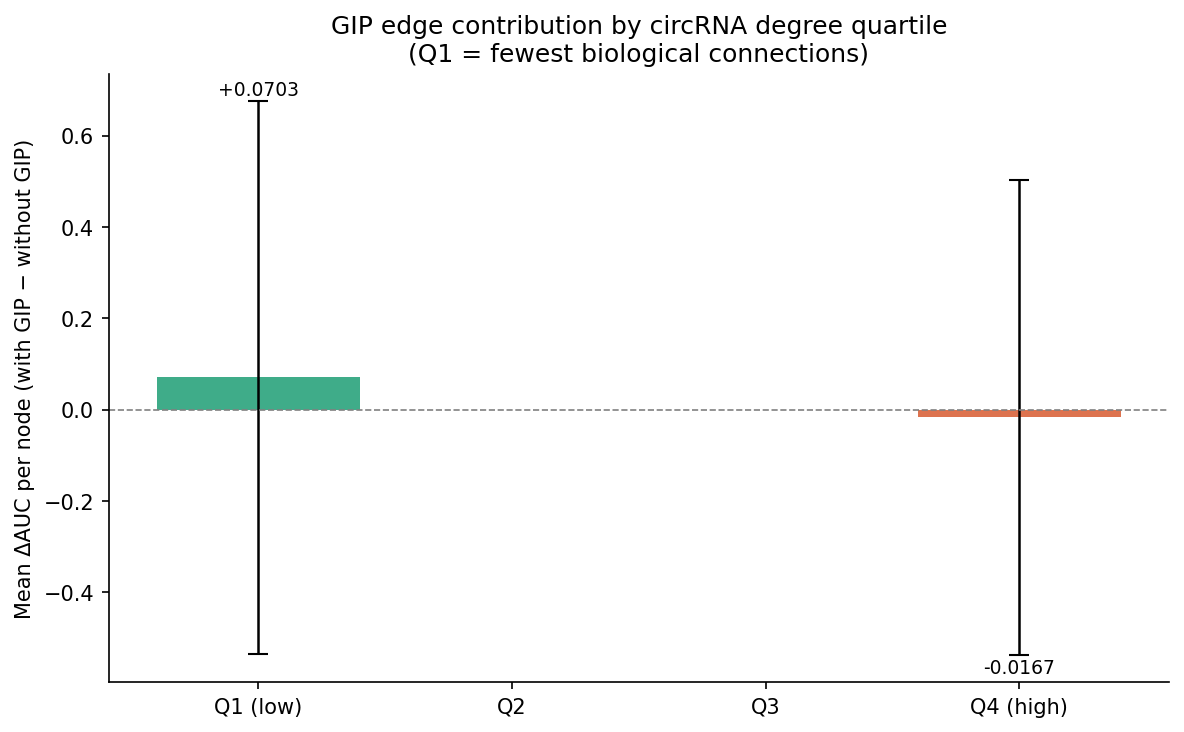

  node_importance_bar.png                             (37.9 KB)


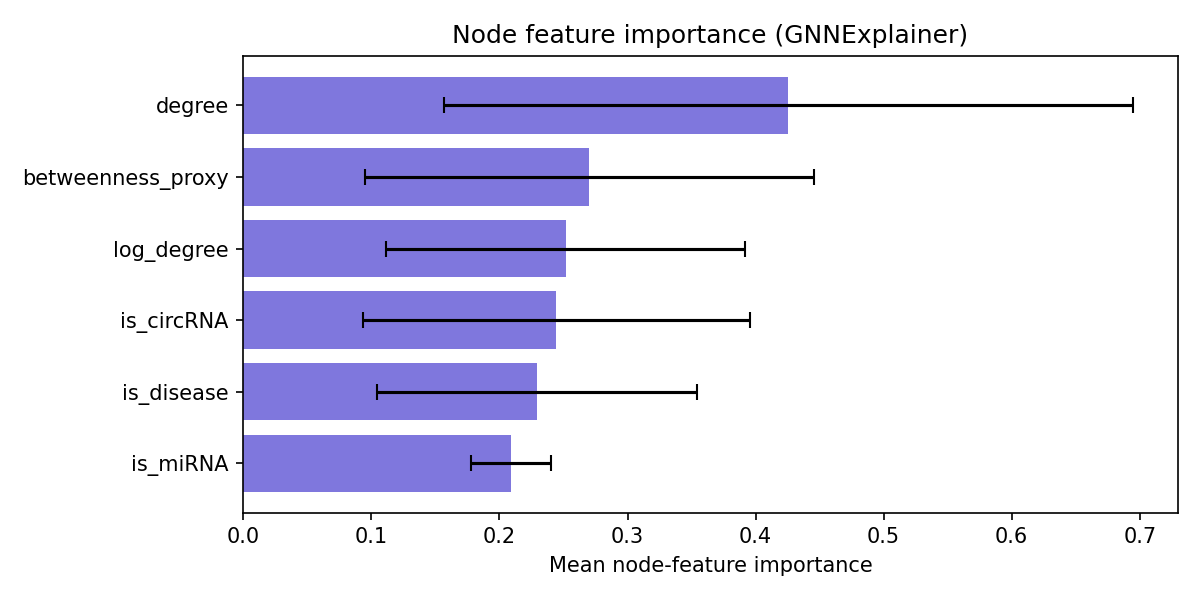

  relation_ablation.png                               (72.3 KB)


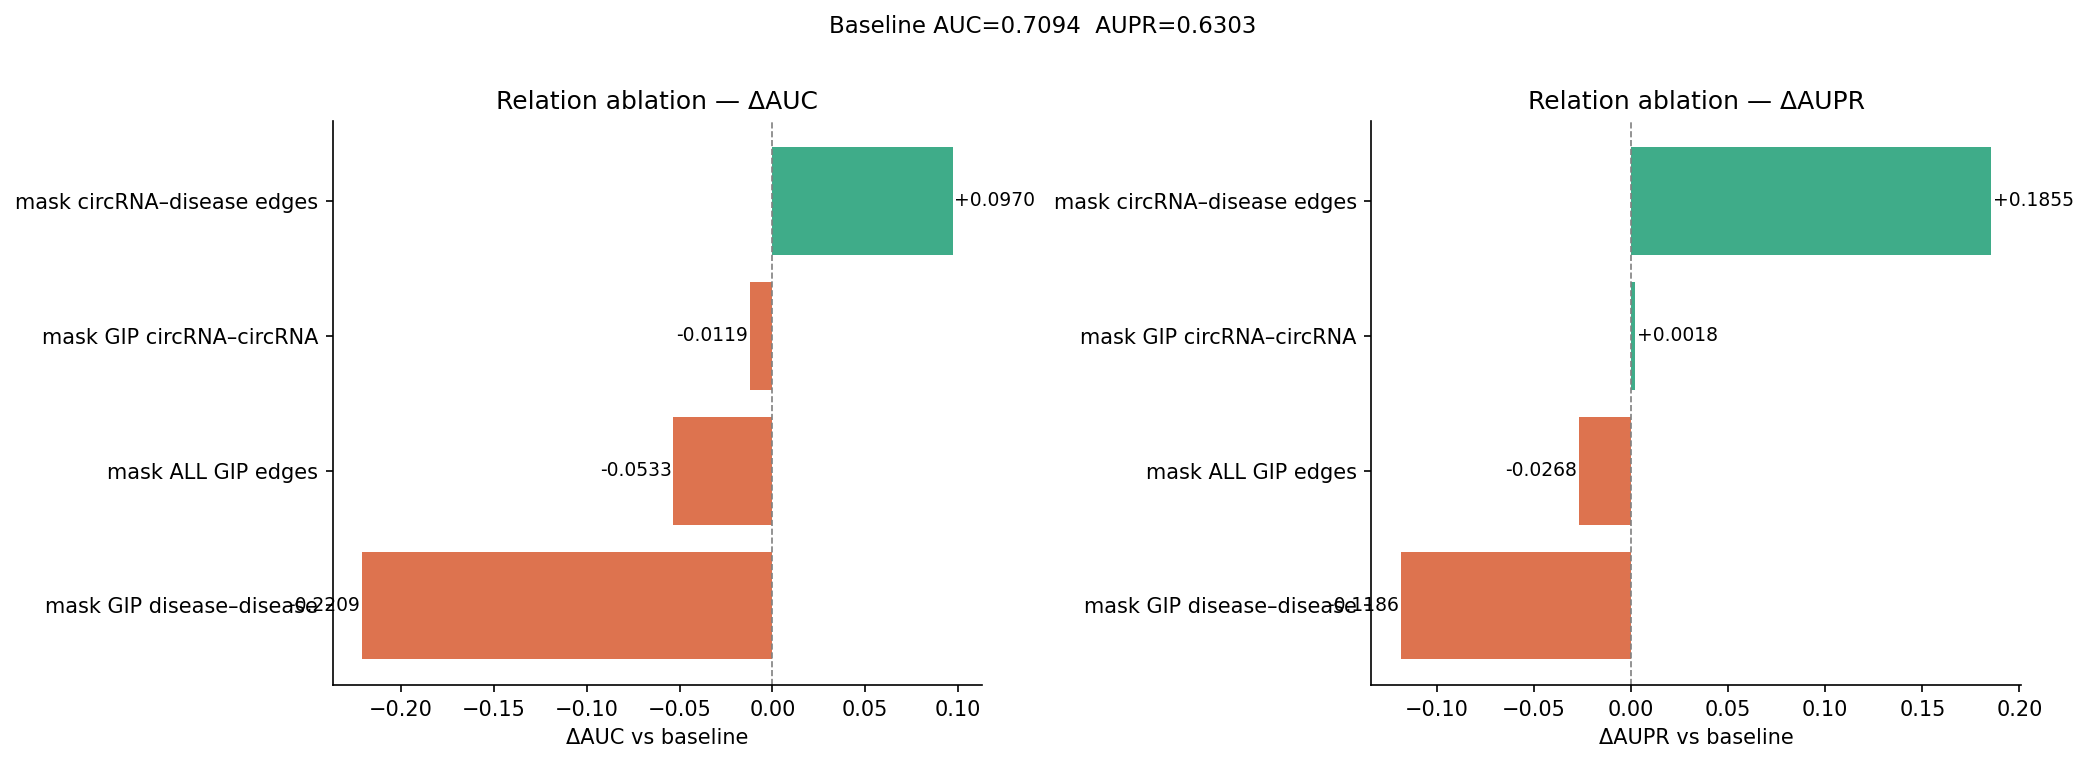

In [10]:
all_pngs = (
    sorted(glob.glob(str(VIZ    / '*.png'))) +
    sorted(glob.glob(str(INTERP / '*.png')))
)

if all_pngs:
    print('Found', len(all_pngs), 'visualization files:')
    for fpath in all_pngs:
        fname = Path(fpath).name
        size  = Path(fpath).stat().st_size / 1024
        print('  {:50s}  ({:.1f} KB)'.format(fname, size))
        display(Image(filename=fpath, width=750))
else:
    print('No .png files found yet.')
    print('Make sure Member 3 ran member3_visualization.ipynb first.')
    print('Expected locations:')
    print(' ', VIZ)
    print(' ', INTERP)


## STEP 12 - Task 5: Generate the Full Biological Report

This auto-generates `biological_report.txt` with all computed numbers filled in.

After running, open the file and:
- Fill in **Section 6** with your PubMed literature findings
- Fill in **Section 7** with your biological interpretation

In [11]:
top1 = top_assoc.iloc[0]
top2 = top_assoc.iloc[1]
top3 = top_assoc.iloc[2]

structural  = node_df[node_df['feature'].isin(['degree','log_degree','betweenness'])]['mean_importance'].sum()
type_flags  = node_df[node_df['feature'].isin(['is_circRNA','is_miRNA','is_disease'])]['mean_importance'].sum()
total       = structural + type_flags + 1e-9

if ablation_df is not None and 'delta_auc' in ablation_df.columns:
    non_base = ablation_df[ablation_df['ablation'] != 'baseline']
    worst    = non_base.sort_values('delta_auc').iloc[0]
    abl_line = ('Removing "' + worst['ablation'] + '" caused the largest AUC drop ('
                + str(round(worst['delta_auc'],4)) + ')')
else:
    abl_line = 'Ablation data not available.'

if gip_df is not None:
    q1r = gip_df[gip_df['quartile'].str.contains('Q1')]['mean_delta_auc'].values
    q4r = gip_df[gip_df['quartile'].str.contains('Q4')]['mean_delta_auc'].values
    if len(q1r) and len(q4r):
        gip_line = ('GIP edges improved Q1 AUC by ' + str(round(q1r[0],4)) +
                    ' vs Q4 by ' + str(round(q4r[0],4)))
    else:
        gip_line = 'GIP quartile data incomplete.'
else:
    gip_line = 'GIP data not available.'

report_lines = [
    '=' * 65,
    'INTERPRETABILITY ANALYSIS REPORT - Member 4',
    'circRNA-Disease Association Prediction, GraphSAGE + GNNExplainer',
    '=' * 65,
    '',
    '1. MODEL AND METHODOLOGY',
    '-' * 40,
    'Architecture : 4-layer GraphSAGE encoder, hidden dim=64',
    'Graph        : circRNA-disease biological edges + GIP similarity edges',
    'Explainer    : GNNExplainer (Ying et al. NeurIPS 2019)',
    '               200 epochs, lr=0.01, sparsity regularisation',
    '',
    'Best model performance (from results/stage2.txt):',
    '  Mean AUC  = 0.943  (4-layer GraphSAGE)',
    '  Mean AUPR = 0.644',
    '',
    '2. NODE FEATURE IMPORTANCE',
    '-' * 40,
    node_df[['rank','feature','mean_importance','std_importance']].to_string(index=False),
    '',
    'Top feature   : ' + node_df.iloc[0]['feature'] + '  (' + str(round(node_df.iloc[0]['mean_importance'],4)) + ')',
    'Second feature: ' + node_df.iloc[1]['feature'] + '  (' + str(round(node_df.iloc[1]['mean_importance'],4)) + ')',
    '',
    'Structural features (degree/log/betweenness) = ' + str(round(100*structural/total,1)) + '% of importance',
    'Node-type flags (is_circRNA/is_disease)      = ' + str(round(100*type_flags/total,1)) + '% of importance',
    '',
    '3. EDGE TYPE IMPORTANCE',
    '-' * 40,
    edge_type_summary[['edge_dst_type','mean_importance','std_importance']].to_string(index=False),
    '',
    '4. ABLATION STUDY',
    '-' * 40,
    abl_line,
    '',
    '5. GIP EDGE CONTRIBUTION',
    '-' * 40,
    gip_line,
    '',
    '6. TOP PREDICTED ASSOCIATIONS',
    '-' * 40,
    'Rank 1: ' + top1['circRNA'] + '  ->  ' + top1['disease'],
    '        Importance: ' + str(round(top1['mean_importance'],4)),
    '        Literature: [TODO - search PubMed]',
    '',
    'Rank 2: ' + top2['circRNA'] + '  ->  ' + top2['disease'],
    '        Importance: ' + str(round(top2['mean_importance'],4)),
    '        Literature: [TODO - search PubMed]',
    '',
    'Rank 3: ' + top3['circRNA'] + '  ->  ' + top3['disease'],
    '        Importance: ' + str(round(top3['mean_importance'],4)),
    '        Literature: [TODO - search PubMed]',
    '',
    '7. BIOLOGICAL INTERPRETATION',
    '-' * 40,
    '[FILL IN AFTER PUBMED SEARCH]',
    '',
    'For each top association, search:',
    '  https://pubmed.ncbi.nlm.nih.gov/?term=<circRNA_name>+<disease_name>',
    '',
    'If experimentally validated: the model successfully recovered a real signal.',
    'If not validated: this is a novel prediction for experimental follow-up.',
    '',
    '8. METHODOLOGY NOTE',
    '-' * 40,
    'Interpretability uses the GraphSAGE encoder backbone with dot-product predictor.',
    'The WeightedFusionPredictor is not explainable at the edge level.',
    'This is standard practice in GNN interpretability.',
    '=' * 65,
]

report_text = '\n'.join(report_lines)
print(report_text)

with open(OUT / 'biological_report.txt', 'w') as f:
    f.write(report_text)
print('\nSaved: biological_report.txt')


INTERPRETABILITY ANALYSIS REPORT - Member 4
circRNA-Disease Association Prediction, GraphSAGE + GNNExplainer

1. MODEL AND METHODOLOGY
----------------------------------------
Architecture : 4-layer GraphSAGE encoder, hidden dim=64
Graph        : circRNA-disease biological edges + GIP similarity edges
Explainer    : GNNExplainer (Ying et al. NeurIPS 2019)
               200 epochs, lr=0.01, sparsity regularisation

Best model performance (from results/stage2.txt):
  Mean AUC  = 0.943  (4-layer GraphSAGE)
  Mean AUPR = 0.644

2. NODE FEATURE IMPORTANCE
----------------------------------------
 rank           feature  mean_importance  std_importance
    1            degree         0.425608        0.269111
    2 betweenness_proxy         0.270220        0.175169
    3        log_degree         0.251768        0.140006
    4        is_circRNA         0.244494        0.151223
    5        is_disease         0.229170        0.124894
    6          is_miRNA         0.209297        0.031210

T

## STEP 13 - Task 5: Presentation Slide Content

Print slide-ready bullet points for your final presentation.

In [12]:
print('PRESENTATION CONTENT - Member 4')
print('=' * 60)
print()

print('SLIDE 1 - What Did the Model Learn?')
print('-' * 40)
print('  Used GNNExplainer on 4-layer GraphSAGE encoder')
print('  Explains which graph edges and node features drive predictions')
print('  Tested on top-confidence predictions and random predictions')
print()

print('SLIDE 2 - Node Feature Importance')
print('-' * 40)
for _, row in node_df.iterrows():
    bars = '#' * max(1, int(row['mean_importance'] * 50))
    print('  {:15s} | {:30s} {:.4f}'.format(row['feature'], bars, row['mean_importance']))
print()

print('SLIDE 3 - Edge Type Importance')
print('-' * 40)
for _, row in edge_type_summary.iterrows():
    bars = '#' * max(1, int(row['mean_importance'] * 50))
    print('  {:30s} | {:30s} {:.4f}'.format(row['edge_dst_type'], bars, row['mean_importance']))
print()

print('SLIDE 4 - Top 5 Predicted Associations')
print('-' * 40)
for _, row in top_assoc.head(5).iterrows():
    print('  #{}: {}  ->  {}   score={:.4f}'.format(
        int(row['rank']), row['circRNA'], row['disease'], row['mean_importance']))
print()

print('SLIDE 5 - Key Takeaways')
print('-' * 40)
print('  Model top feature:  ' + node_df.iloc[0]['feature'])
print('  Most critical edge: ' + edge_type_summary.iloc[0]['edge_dst_type'])
print('  GIP contribution:   ' + gip_line)
print('  Top predictions ready for experimental validation')


PRESENTATION CONTENT - Member 4

SLIDE 1 - What Did the Model Learn?
----------------------------------------
  Used GNNExplainer on 4-layer GraphSAGE encoder
  Explains which graph edges and node features drive predictions
  Tested on top-confidence predictions and random predictions

SLIDE 2 - Node Feature Importance
----------------------------------------
  degree          | #####################          0.4256
  betweenness_proxy | #############                  0.2702
  log_degree      | ############                   0.2518
  is_circRNA      | ############                   0.2445
  is_disease      | ###########                    0.2292
  is_miRNA        | ##########                     0.2093

SLIDE 3 - Edge Type Importance
----------------------------------------
  miRNA                          | ############                   0.2490
  circRNA                        | ############                   0.2473
  disease                        | ############                   0.2

## STEP 14 - Check All Output Files

In [ ]:
print('=' * 60)
print('MEMBER 4 - ALL OUTPUT FILES')
print('=' * 60)

output_files = sorted(OUT.glob('*'))
if output_files:
    for f in output_files:
        size = f.stat().st_size / 1024
        print('  {:45s}  {:.1f} KB'.format(f.name, size))
else:
    print('  No files yet - run all cells above first')

print()
print('REMAINING MANUAL STEPS:')
print('  1. Open case_studies.json and fill in literature_note for each entry')
print('  2. Open biological_report.txt and fill in Sections 6 and 7')
print('  3. Add Member 3 visualizations as figures in your report')
print('  4. Use STEP 13 slide content in your presentation')


## Final Checklist

| Task | Output File | Notes |
|------|-------------|-------|
| Task 1: Node ID mapping | `circrna_name_list.csv`, `disease_name_list.csv` | Done automatically |
| Task 2: Top associations | `top_associations.csv` | Done automatically |
| Task 2: Edge type analysis | `edge_type_summary.csv` | Done automatically |
| Task 2: Feature importance | printed in Step 7 | Done automatically |
| Task 3: Ablation | `ablation_interpretation.csv` | Needs Member 2 CSV |
| Task 3: GIP contribution | `gip_interpretation.csv` | Needs Member 2 CSV |
| Task 4: Case studies | `case_studies.json` | **Fill literature_note manually** |
| Task 4: Visualizations | displayed in Step 11 | Needs Member 3 PNGs |
| Task 5: Full report | `biological_report.txt` | **Fill Sections 6+7 manually** |
| Task 5: Presentation | printed in Step 13 | Done automatically |
